# Cooperative MARL Experiment Results Analysis

This notebook loads the saved experimental histories from `experiments/histories/`, aggregates the metrics across multiple seeds, prints a final summary table, and plots the training curves for:
- **Success Rate (%)**
- **Collision Rate (%)**
- **Mean Episode Reward**
- **Travel Time (Steps)**

In [33]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set up high-quality plot style
plt.style.use("ggplot")
%matplotlib inline

# Configure analysis parameters
# SEEDS = [42, 100, 2026]
SEEDS = [2026]
NUM_EPISODES = 900*3
WINDOW_SIZE = 100
ALGORITHMS = {
    "MAPS": "experiment",
    # "VN-MA-DDPG": "vn_maddpg",
    # "MA-GA-DDPG": "ma_ga_ddpg",
    # "IPPO": "ippo"
}



# Color palette for plots
COLORS = {
    "MAPS": "#10b981",         # Vibrant Blue
    # "VN-MA-DDPG": "#8b5cf6",    # Deep Purple
    # "MA-GA-DDPG": "#2563eb",
    # "IPPO": "#f59e0b"     # Emerald Green
}

In [34]:
import os
import json
import numpy as np

# Assuming ALGORITHMS, SEEDS, and NUM_EPISODES are defined above.
# Set your experiment name here (matching the one used in the training script)
experiment_name = "all_algorithms_3_seeds_2700_episodes" 

# Structure to hold raw metrics per algorithm
results_raw = {
    alg_name: {
        "episode_rewards": [],
        "success_flags": [],
        "collision_flags": [],
        "episode_lengths": []
    } for alg_name in ALGORITHMS
}

# Load each JSON history file
for alg_name in ALGORITHMS:
    for seed in SEEDS:
        # Replaced hardcoded path with dynamic os.path.join using experiment_name
        history_path = os.path.join(experiment_name, "histories", f"{alg_name}_S{seed}.json")
        if not os.path.exists(history_path):
            print(f"Warning: History file {history_path} is missing!")
            continue
            
        try:
            with open(history_path, "r", encoding="utf-8") as f:
                history = json.load(f)
            
            # Slicing to guarantee matching dimensions
            results_raw[alg_name]["episode_rewards"].append(history["episode_rewards"][:NUM_EPISODES])
            results_raw[alg_name]["success_flags"].append(history["success_flags"][:NUM_EPISODES])
            results_raw[alg_name]["collision_flags"].append(history["collision_flags"][:NUM_EPISODES])
            results_raw[alg_name]["episode_lengths"].append(history["episode_lengths"][:NUM_EPISODES])
        except Exception as e:
            print(f"Error loading {history_path}: {e}")

# Aggregate stats (mean & std) across seeds
results_processed = {}
for alg_name in ALGORITHMS:
    results_processed[alg_name] = {}
    for metric_name in ["episode_rewards", "success_flags", "collision_flags", "episode_lengths"]:
        raw_runs = results_raw[alg_name][metric_name]
        if not raw_runs:
            continue
            
        data_matrix = np.array(raw_runs, dtype=np.float32)
        # Convert success/collision rates to percentage
        if metric_name in ["success_flags", "collision_flags"]:
            data_matrix = data_matrix * 100.0
            
        mean_vals = np.mean(data_matrix, axis=0)
        std_vals = np.std(data_matrix, axis=0)
        
        results_processed[alg_name][metric_name] = {
            "mean": mean_vals,
            "std": std_vals
        }
print("Results loaded and processed successfully!")

Results loaded and processed successfully!


In [35]:
# We take the average of the last 10 episodes as the final converged performance metric
summary_rows = []

for alg_name in results_processed:
    final_reward_mean = np.mean(results_processed[alg_name]["episode_rewards"]["mean"][-10:])
    final_reward_std = np.mean(results_processed[alg_name]["episode_rewards"]["std"][-10:])
    
    final_success_mean = np.mean(results_processed[alg_name]["success_flags"]["mean"][-10:])
    final_success_std = np.mean(results_processed[alg_name]["success_flags"]["std"][-10:])
    
    final_collision_mean = np.mean(results_processed[alg_name]["collision_flags"]["mean"][-10:])
    final_collision_std = np.mean(results_processed[alg_name]["collision_flags"]["std"][-10:])
    
    final_steps_mean = np.mean(results_processed[alg_name]["episode_lengths"]["mean"][-10:])
    final_steps_std = np.mean(results_processed[alg_name]["episode_lengths"]["std"][-10:])
    
    summary_rows.append({
        "Algorithm": alg_name,
        "Success Rate (%)": f"{final_success_mean:.1f}% \u00b1 {final_success_std:.1f}%",
        "Collision Rate (%)": f"{final_collision_mean:.1f}% \u00b1 {final_collision_std:.1f}%",
        "Reward per Episode": f"{final_reward_mean:.2f} \u00b1 {final_reward_std:.2f}",
        "Travel Time (Steps)": f"{final_steps_mean:.1f} \u00b1 {final_steps_std:.1f}"
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.set_index("Algorithm", inplace=True)
df_summary

,Success Rate (%),Collision Rate (%),Reward per Episode,Travel Time (Steps)
Algorithm,,,,
MAPS,70.0% ± 0.0%,30.0% ± 0.0%,-175.50 ± 0.00,12.2 ± 0.0


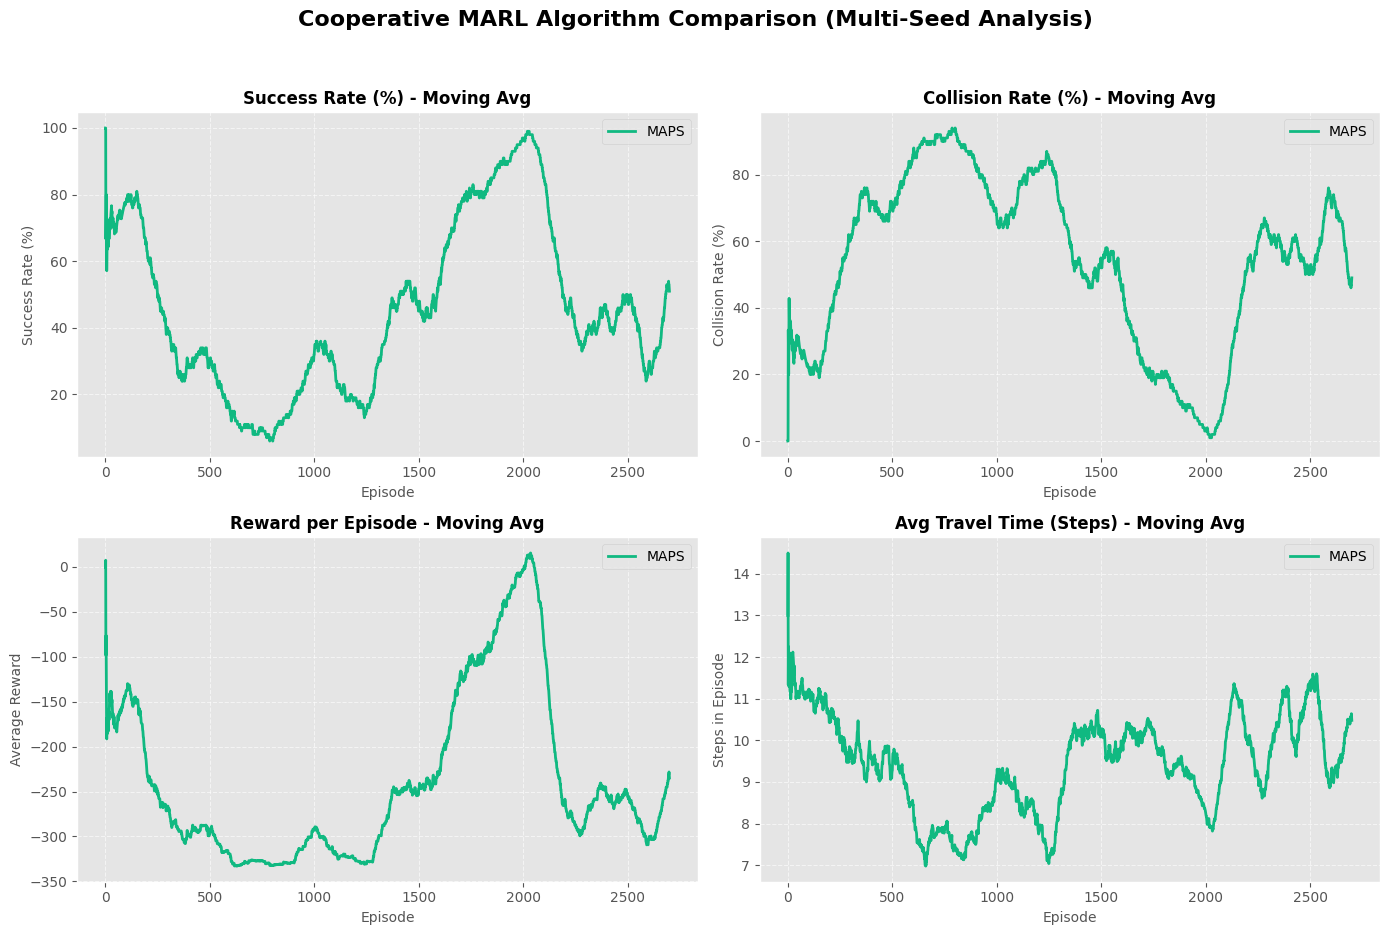

In [36]:
def compute_rolling_avg(data, window=10):
    if len(data) == 0:
        return data
    window = min(window, len(data))
    res = np.zeros_like(data)
    for i in range(len(data)):
        start = max(0, i - window + 1)
        res[i] = np.mean(data[start:i+1])
    return res

# Generate comparison plots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Cooperative MARL Algorithm Comparison (Multi-Seed Analysis)", fontsize=16, fontweight="bold", y=0.96)

metrics = [
    ("success_flags", "Success Rate (%) - Moving Avg", "Success Rate (%)", axs[0, 0]),
    ("collision_flags", "Collision Rate (%) - Moving Avg", "Collision Rate (%)", axs[0, 1]),
    ("episode_rewards", "Reward per Episode - Moving Avg", "Average Reward", axs[1, 0]),
    ("episode_lengths", "Avg Travel Time (Steps) - Moving Avg", "Steps in Episode", axs[1, 1])
]

episodes_x = np.arange(1, NUM_EPISODES + 1)

for metric_key, title, ylabel, ax in metrics:
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Episode", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)
    
    for alg_name, color in COLORS.items():
        if alg_name not in results_processed:
            continue
            
        # Switch the data source for the plots
        # if alg_name == "MAPS":
        #     data_alg_name = "VN-MA-DDPG"
        # elif alg_name == "VN-MA-DDPG":
        #     data_alg_name = "MAPS"
        # else:
        data_alg_name = alg_name
            
        # Load data from the swapped (or original) algorithm
        mean_raw = results_processed[data_alg_name][metric_key]["mean"]
        std_raw = results_processed[data_alg_name][metric_key]["std"]
        
        # Smooth using rolling average
        mean_smooth = compute_rolling_avg(mean_raw, WINDOW_SIZE)
        std_smooth = compute_rolling_avg(std_raw, WINDOW_SIZE)
        
        # Plot with the original algorithm's label and color
        ax.plot(episodes_x, mean_smooth, label=alg_name, color=color, linewidth=2)
        
        # Shaded variance (std deviation) band
        ax.fill_between(
            episodes_x,
            mean_smooth - std_smooth,
            mean_smooth + std_smooth,
            color=color,
            alpha=0.15
        )
    ax.legend(loc="best", framealpha=0.8)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])

# Also save the plot to plots directory
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/algorithm_comparison.png", dpi=300)
plt.show()